# Estimation of R
Rを求めて海表面情報を探索する試み。

In [1]:
# 依存パッケージをimport

import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pywt

# import gnssrefl functions
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.gnssir_cl import gnssir

#@formatter:off
%matplotlib inline

## RINEX → SNR

下記ディレクトリにRINEXファイルを入れる。

refl_code/yyyy/rinex/TTTT/TTTTXXX0.yyo
- yyyy：西暦
- TTTT：局名。アルファベット4文字。
- XXX：day of year
- yy：西暦下二桁

In [2]:
year = 2020
doy = 277
doy_end = 288
station = "calc"

rinex2snr(station, year, doy, doy_end=doy_end, nolook=True)

Using JSON file: /etc/gnssrefl/refl_code/input/calc/calc.json
Using snr value of  66
Using default orbit for this time period:  nav
Using archive value of  all
Station  calc  has four characters, assume RINEX 2.11 format
No parallel processing
SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2770.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2780.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2790.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2800.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2810.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2820.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2830.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2840.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2850.20.snr66 

SNR file already e

## SNRファイルの読み込み

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# SNR ファイルのカラム名（マニュアル準拠）
SNR_COLUMNS_FULL = [
    "sat",              # 衛星番号
    "elev_deg",         # 仰角 [deg]
    "az_deg",           # 方位角 [deg]
    "sec_of_day",       # 秒（GPS time）
    "edot_deg_per_s",   # 仰角変化率 [deg/s]
    "snr_L6",           # S6 (L6) SNR [dB-Hz]
    "snr_L1",           # S1 (L1)
    "snr_L2",           # S2 (L2)
    "snr_L5",           # S5 (L5)
    "snr_L7",           # S7 (L7)
    "snr_L8",           # S8 (L8)
]


def read_snr_file_gz(path: Path) -> pd.DataFrame:
    """1つの .snr*.gz ファイルを読み込んで DataFrame を返す。"""
    df = pd.read_csv(
        path,
        sep=r"\s+",        # ← FutureWarning 回避
        header=None,
        comment="#",
        compression="gzip",
        engine="python",
    )
    n_cols = df.shape[1]
    df.columns = SNR_COLUMNS_FULL[:n_cols]
    return df


def load_snr_directory(year: int, station: str,
                       base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    /etc/gnssrefl/refl_code/{year}/snr/{station}/ 配下の
    .snr*.gz ファイルだけを全部読み込んで

    - snr_dict: {ファイル名: DataFrame}
    - snr_table: 全ファイルを縦結合した DataFrame
                 (year, station, doy, file などの情報付き)

    を返す。
    """
    snr_dir = Path(base_dir) / str(year) / "snr" / station

    if not snr_dir.is_dir():
        raise FileNotFoundError(f"ディレクトリが見つかりません: {snr_dir}")

    snr_files = sorted(snr_dir.glob("*.snr*.gz"))

    if not snr_files:
        print(f"*.snr*.gz が見つかりません: {snr_dir}")

    snr_dict = {}
    table_list = []

    for f in snr_files:
        df = read_snr_file_gz(f)
        snr_dict[f.name] = df

        # ファイル名から DOY を推定（例: calc2770.20.snr66.gz）
        name_no_gz = f.name[:-3] if f.name.endswith(".snr88.gz") else f.name
        stem = name_no_gz.split(".")[0]   # "calc2770"
        doy = int(stem[len(station):len(station) + 3])  # "277"

        df2 = df.copy()
        df2["year"] = year
        df2["station"] = station
        df2["file"] = f.name
        df2["doy"] = doy
        table_list.append(df2)

    if table_list:
        snr_table = pd.concat(table_list, ignore_index=True)
    else:
        snr_table = pd.DataFrame()

    return snr_dict, snr_table

def main(year: int,
         station: str,
         snr_dict_existing=None,
         base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    - Jupyter で既に snr_dict を作っているなら snr_dict_existing を渡す
    - そうでなければディレクトリから読み込む

    戻り値:
        snr_dict, snr_table
    """
    if snr_dict_existing is None:
        snr_dict, snr_table = load_snr_directory(year, station, base_dir=base_dir)
    else:
        # 既存の snr_dict から snr_table だけ再構成したい場合など
        snr_dict = snr_dict_existing
        # ここで snr_table を組み立て直すなら、上の build 処理を使い回すイメージ
        # 必要なら別関数に分けてもよい
        rows = []
        for fname, df in snr_dict.items():
            name_no_gz = fname[:-3] if fname.endswith(".gz") else fname
            stem = name_no_gz.split(".")[0]
            doy = int(stem[len(station):len(station) + 3])

            tmp = df.copy()
            tmp["year"] = year
            tmp["station"] = station
            tmp["file"] = fname
            tmp["doy"] = doy
            rows.append(tmp)
        snr_table = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    return snr_dict, snr_table


## コヒーレント・インコヒーレント比率を求める

### Plot用

In [4]:
import matplotlib.pyplot as plt

def compute_prominence_from_bgmodel_res(res, h_grid, h0, eps=1e-18):
    """
    Π(e) = P_peak_excess / P_bg_in
      P_peak_excess = res["P_coh"]   (window-integrated excess)
      P_bg_in       = B0(e) * sum_h w_coh(h)
    """
    sigma = float(res["sigma_coh"])
    w = np.exp(-(h_grid - h0)**2 / (2.0 * sigma**2))
    w = np.clip(w, 0.0, 1.0)
    wsum = float(np.sum(w))

    P_peak = np.asarray(res["P_coh"], float)   # excess, already window-integrated
    B0 = np.asarray(res["B0"], float)          # floor per-h-bin
    P_bg_in = B0 * wsum

    Pi = P_peak / (P_bg_in + eps)
    return Pi, P_peak, P_bg_in, wsum


def plot_prominence_for_track(e_deg, Pi, sat, dir_val, doy, signal,
                              e_lim=None, y_lim=None, show=True):
    e_deg = np.asarray(e_deg, float)
    Pi = np.asarray(Pi, float)

    fig, ax = plt.subplots(figsize=(7.8, 3.8))
    ax.plot(e_deg, Pi, lw=1.6)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Elevation [deg]")
    ax.set_ylabel("Prominence Π(e) = P_peak_excess / P_bg_in  (log)")
    ax.set_title(f"Prominence Π(e)  sat={sat} ({dir_val})  {signal}  doy={doy}")

    if e_lim is not None:
        ax.set_xlim(*e_lim)
    if y_lim is not None:
        ax.set_ylim(*y_lim)

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

def plot_R_e(e: np.ndarray, R: np.ndarray, title: str | None = None):
    plt.figure()
    plt.plot(e, R)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    plt.figure()
    R_dB = 10 * np.log10(R)
    plt.plot(e, R_dB)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh [dB]")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    


def plot_wavelet_power_e_h(e_grid, h_grid, P, title=None):
    import numpy as np
    import matplotlib.pyplot as plt

    e_grid = np.asarray(e_grid)
    h_grid = np.asarray(h_grid)
    P = np.asarray(P, float)

    if P.shape != (len(e_grid), len(h_grid)):
        raise ValueError(
            f"P.shape={P.shape}, expected ({len(e_grid)}, {len(h_grid)})"
        )

    # 0 以上に限定
    P[P < 0] = 0.0
    Pmax = np.nanmax(P)
    if not np.isfinite(Pmax) or Pmax <= 0:
        Pmax = 1.0  # 全部ゼロだったときの保険

    E, H = np.meshgrid(e_grid, h_grid, indexing="xy")

    plt.figure()
    pcm = plt.pcolormesh(E, H, P.T, shading="auto", vmin=0.0, vmax=Pmax)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("Height h [m]")
    if title is not None:
        plt.title(title)
    cb = plt.colorbar(pcm)
    cb.set_label(r"$|W(e,h)|^2$")
    plt.tight_layout()
    plt.show()



読み込み完了: 497108 rows


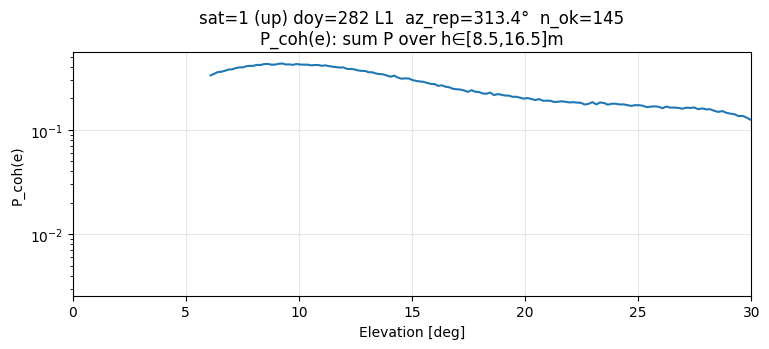

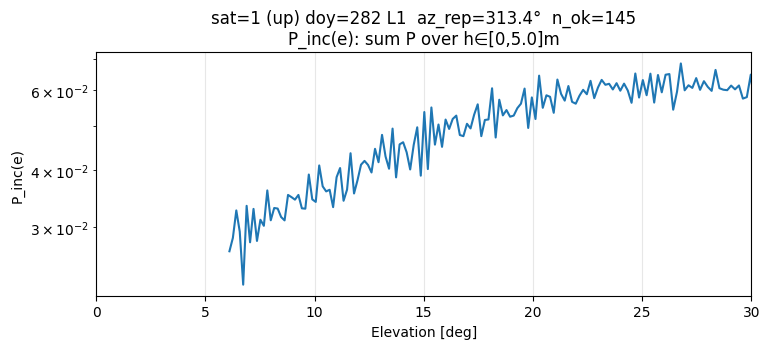

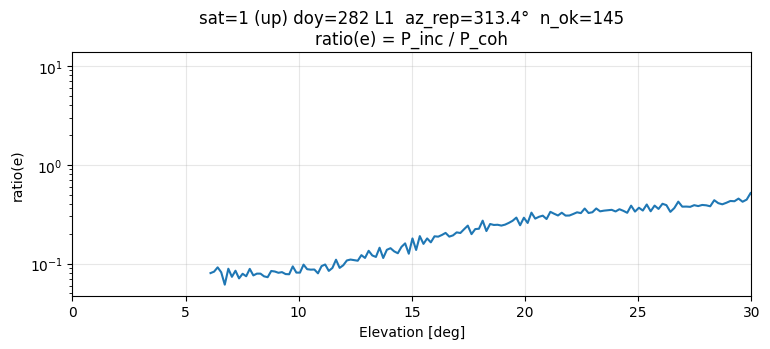

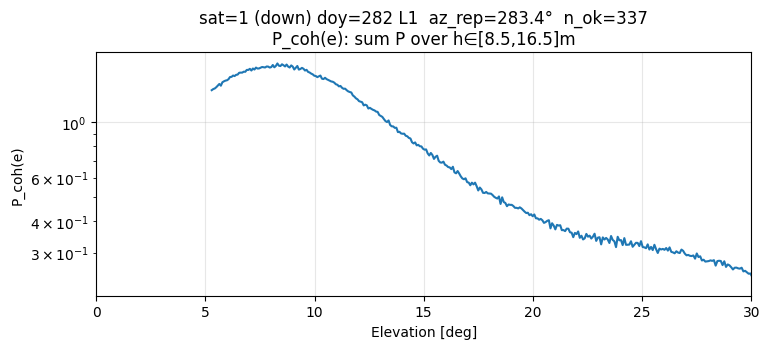

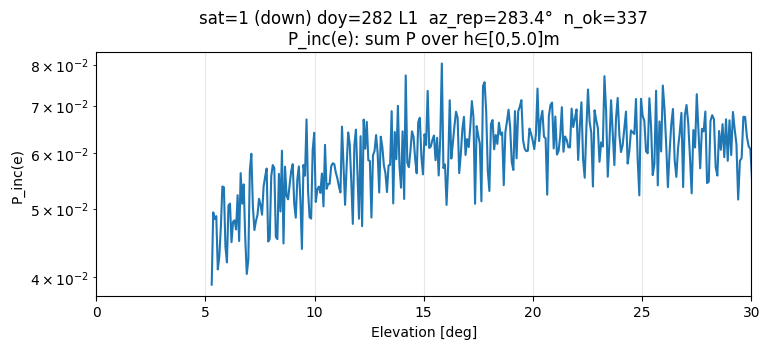

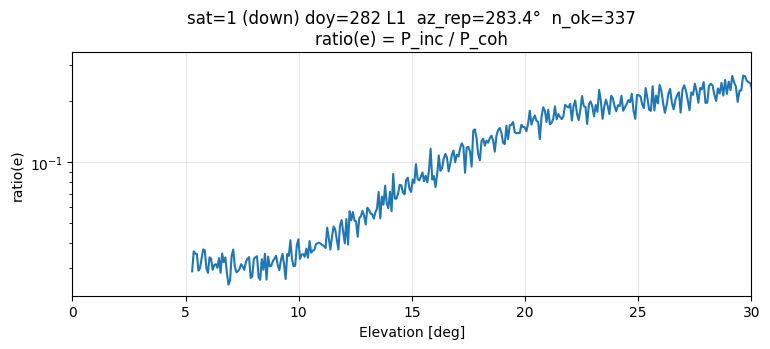

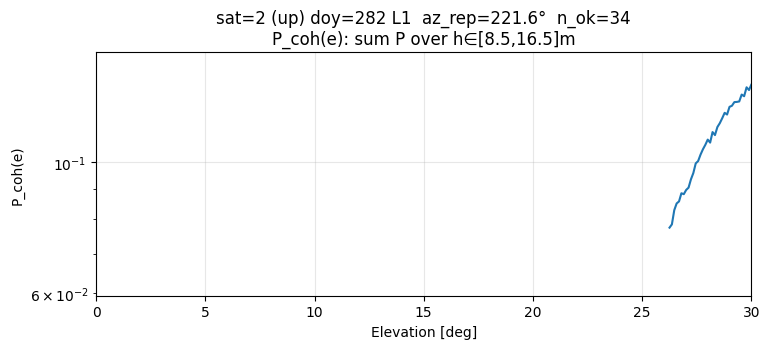

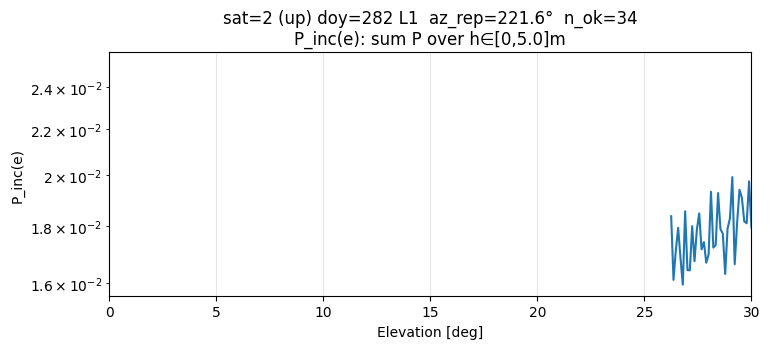

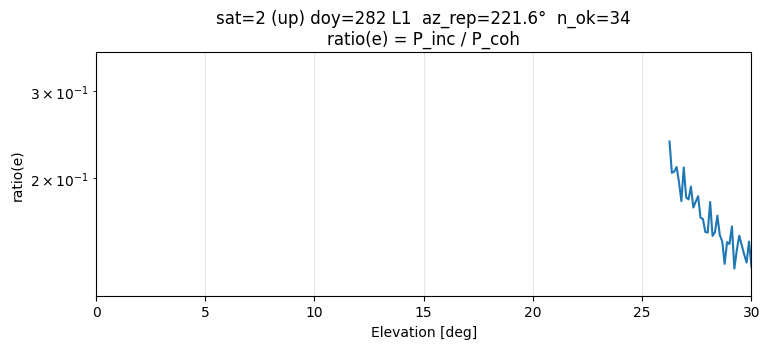

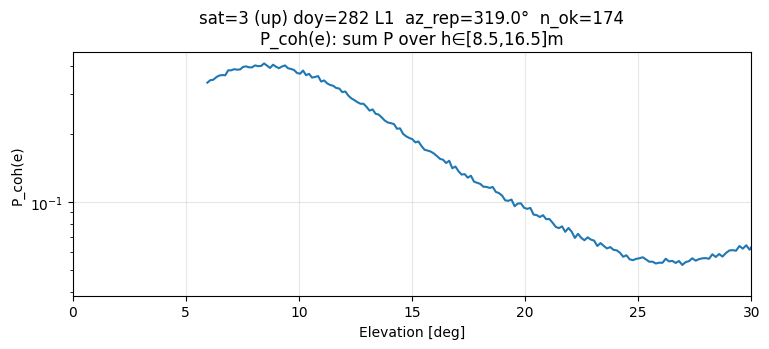

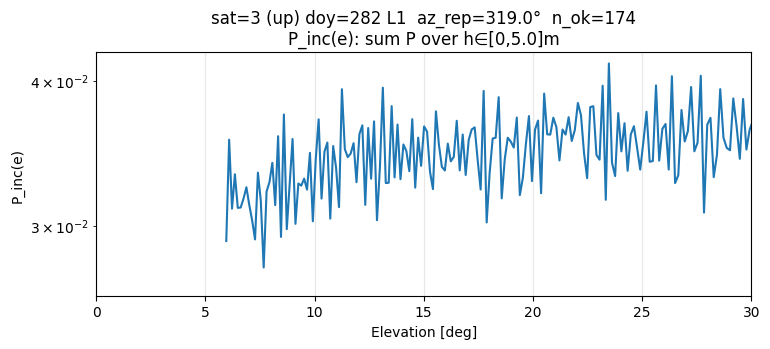

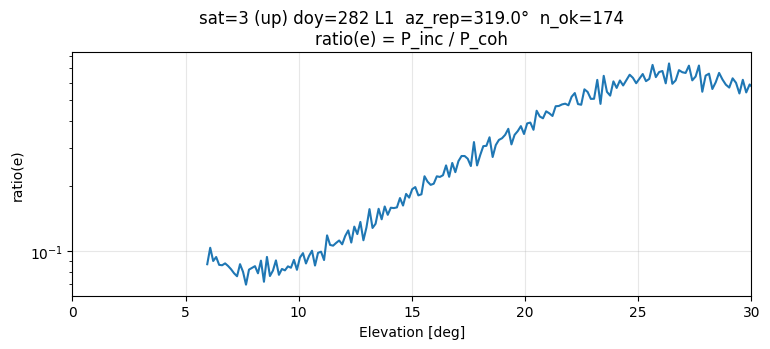

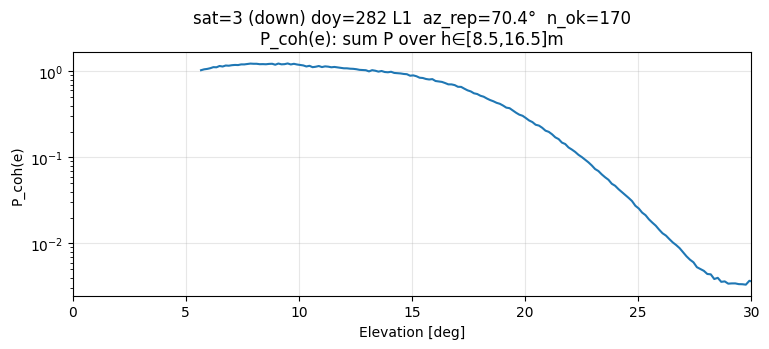

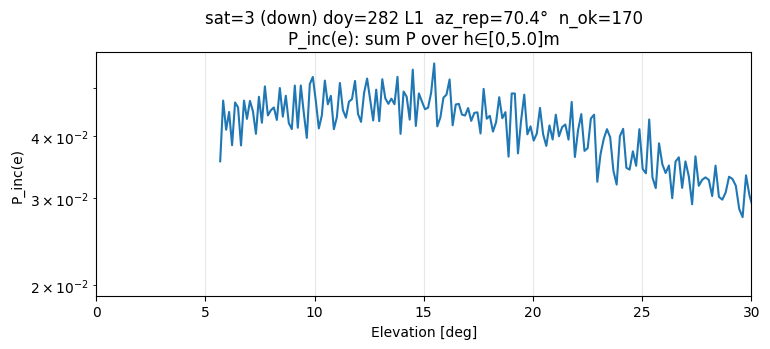

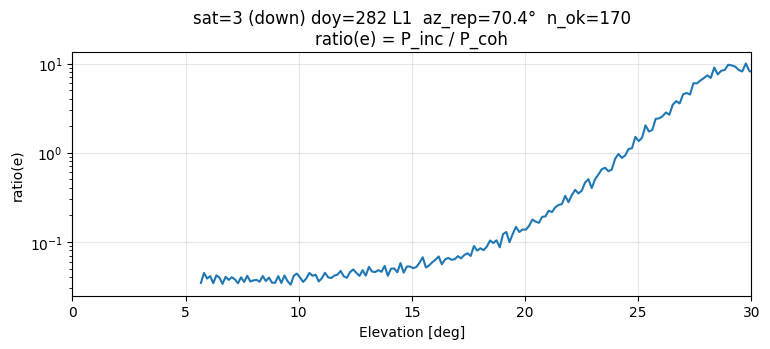

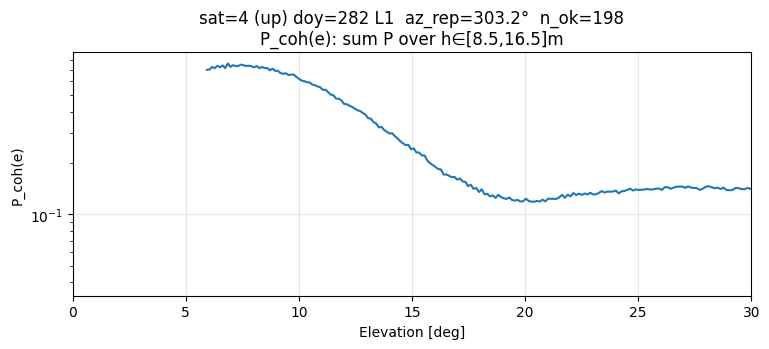

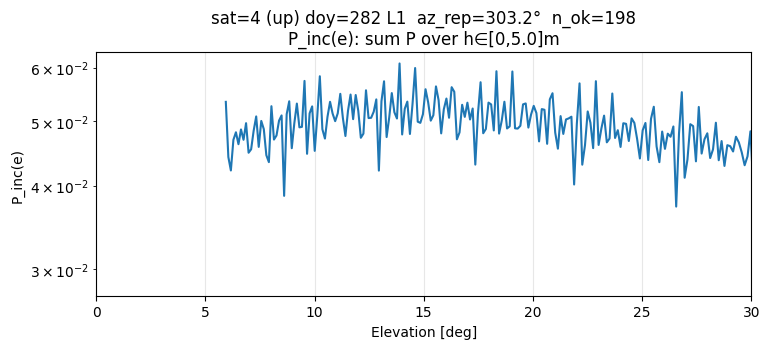

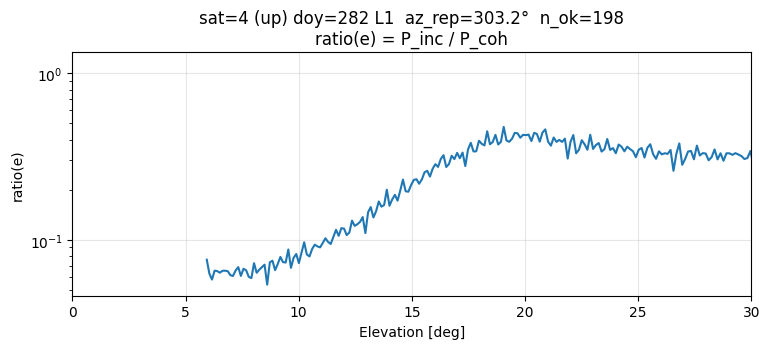

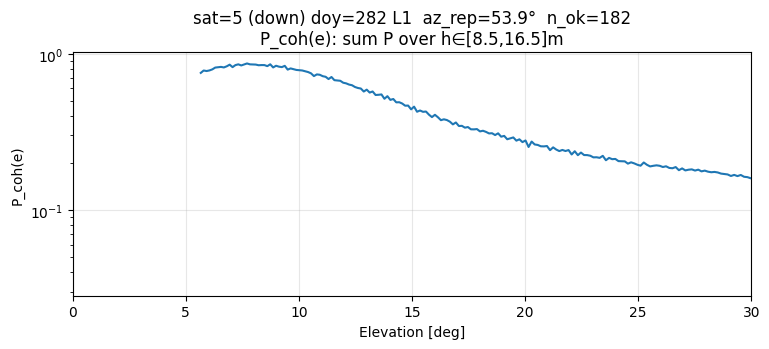

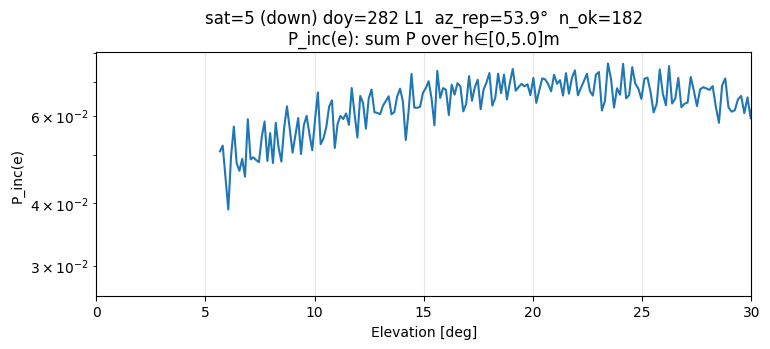

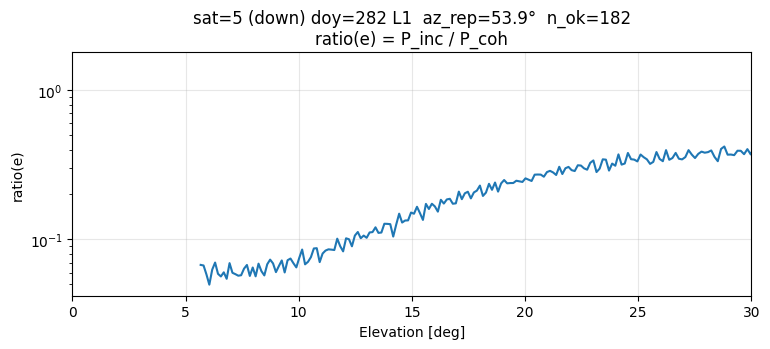

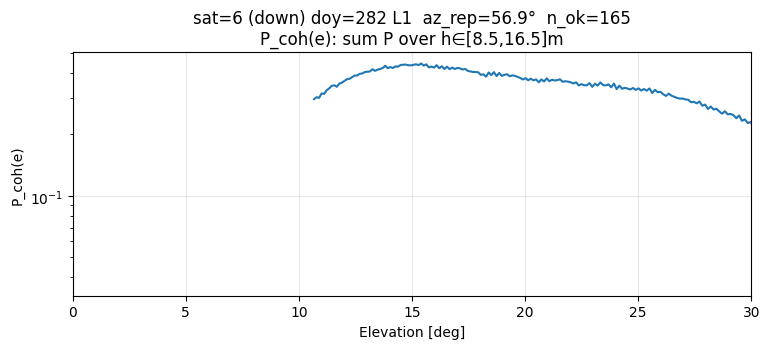

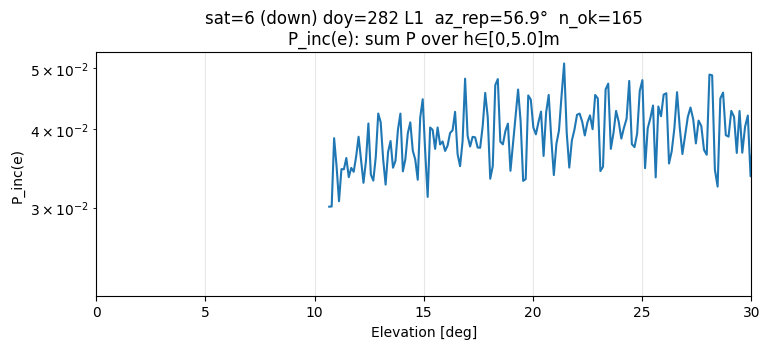

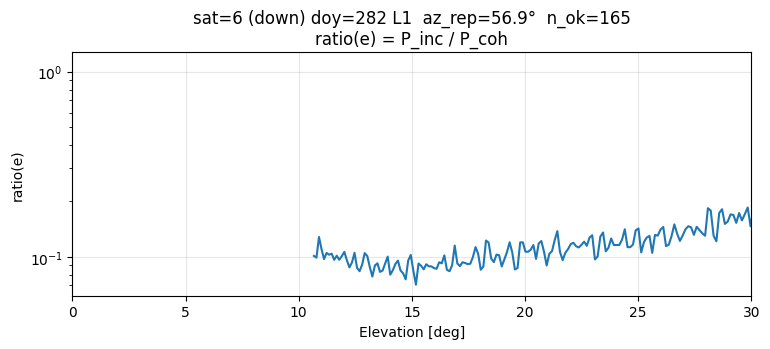

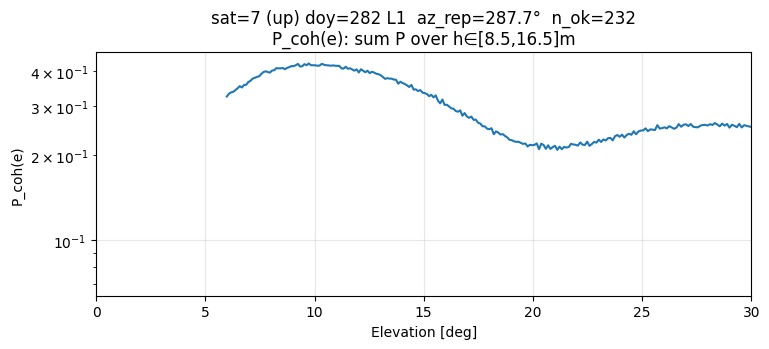

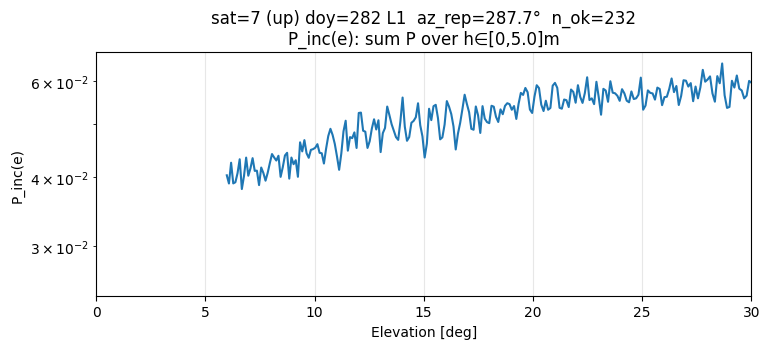

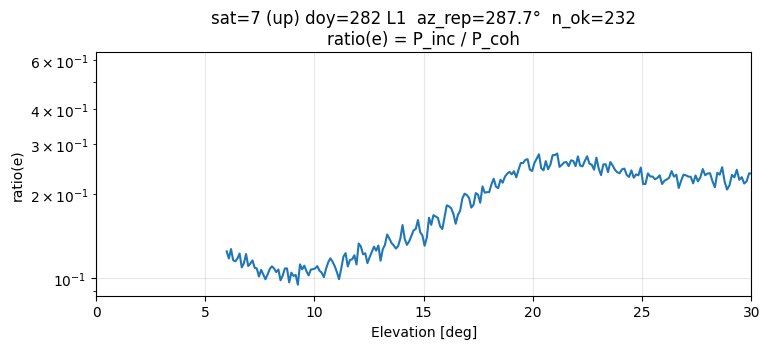

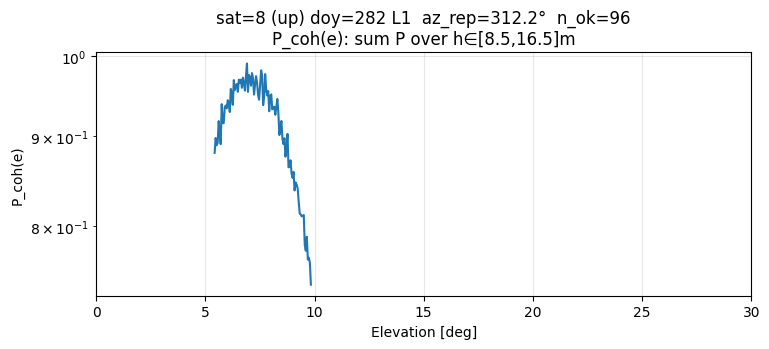

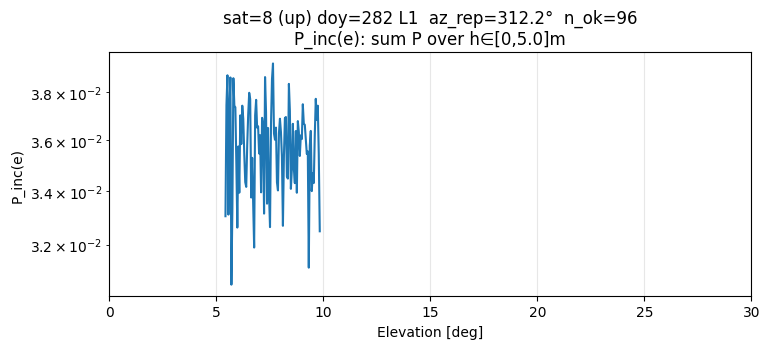

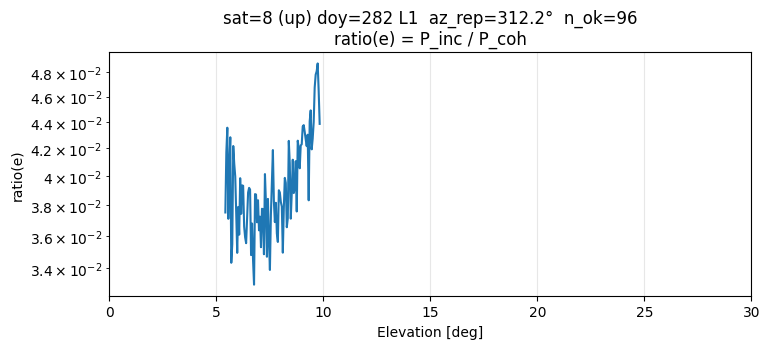

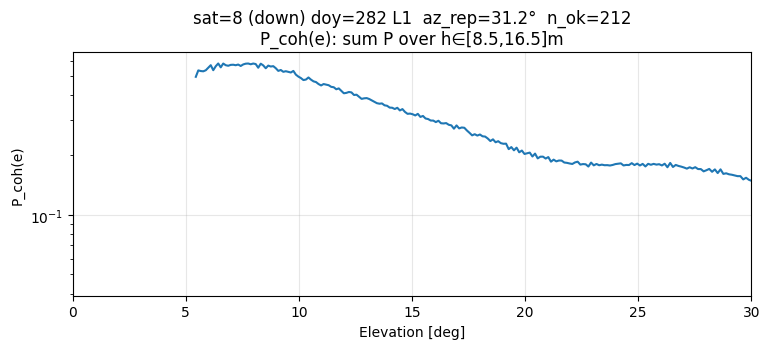

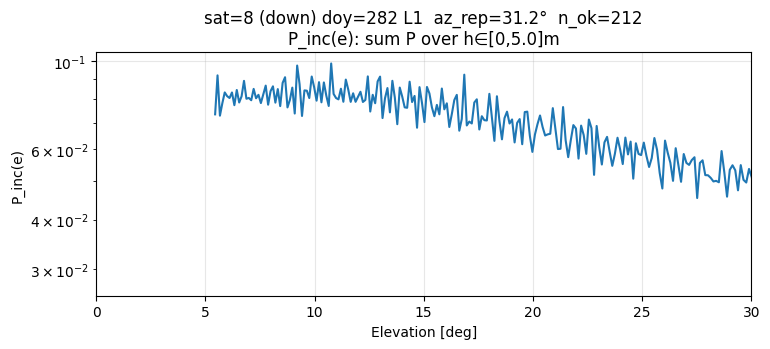

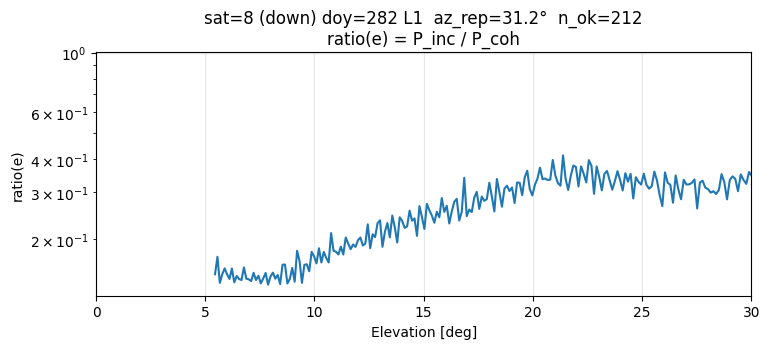

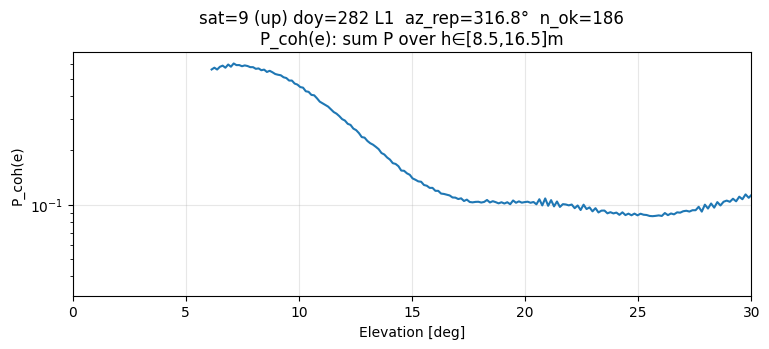

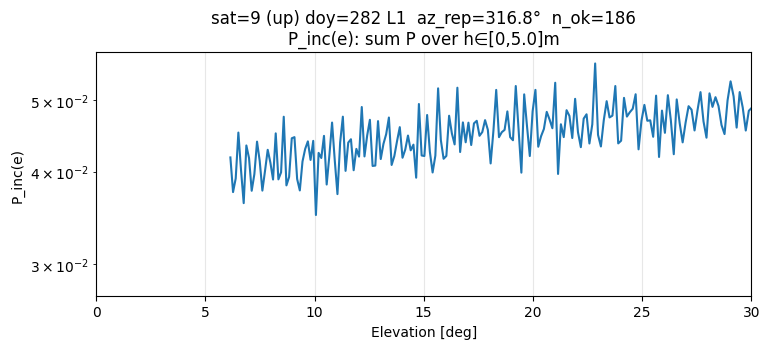

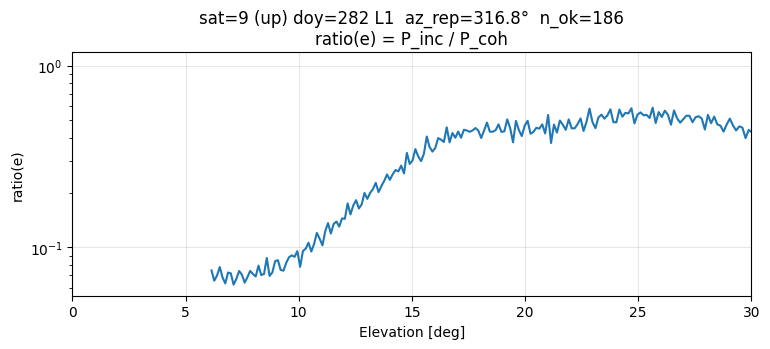

drop_stat: {'no_data': 1, 'short': 4, 'wavelet_fail': 0, 'too_few_valid': 10}
    sat direction  az_rep_deg  Pcoh_rep_median  Pinc_rep_median  \
0     1      down  283.394308         0.572210         0.060335   
1     3      down   70.444073         0.615292         0.042911   
2     5      down   53.865124         0.337773         0.064727   
3     6      down   56.877338         0.364318         0.039092   
4     8      down   31.199459         0.272305         0.072639   
5     9      down   76.826153         0.003461         0.047602   
6    11      down  346.719545         0.367101         0.054140   
7    12      down   72.109203         0.048756         0.034982   
8    13      down  301.743587         0.476486         0.052037   
9    15      down   48.257677         0.335636         0.033786   
10   16      down   48.530608         0.422053         0.054163   
11   21      down   47.241786         0.541147         0.058160   
12   22      down   81.030617         0.064013     

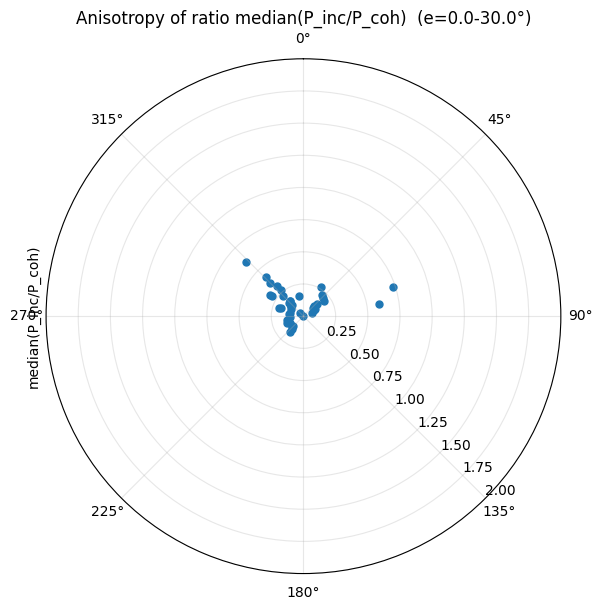

In [12]:
from __future__ import annotations

from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# -----------------------------
# Basic utilities
# -----------------------------
SIGNAL_COL_MAP = {
    "L1": "snr_L1",
    "L2": "snr_L2",
    "L5": "snr_L5",
    "L6": "snr_L6",
    "L7": "snr_L7",
    "L8": "snr_L8",
}

def normalize_angle_deg(angle: float) -> float:
    return float(np.mod(angle, 360.0))

def azimuth_in_range(az_deg: np.ndarray, az_min: float, az_max: float) -> np.ndarray:
    az = np.mod(np.asarray(az_deg, float), 360.0)
    amin = normalize_angle_deg(az_min)
    amax = normalize_angle_deg(az_max)
    if amin <= amax:
        return (az >= amin) & (az <= amax)
    else:
        return (az >= amin) | (az <= amax)

def add_direction_by_elev(df: pd.DataFrame, eps: float = 1e-3) -> pd.DataFrame:
    if df.empty:
        return df.assign(direction_flag=pd.Series(dtype=str))
    d = df.sort_values("sec_of_day").copy()
    de = d["elev_deg"].diff().to_numpy()
    if len(de) >= 2 and np.isnan(de[0]):
        de[0] = de[1]
    de = np.nan_to_num(de, nan=0.0)
    d["direction_flag"] = np.where(de > eps, "up", np.where(de < -eps, "down", "flat"))
    return d

def select_observations(
    snr_table: pd.DataFrame,
    *,
    doy: int | None = None,
    sat: int | None = None,
    signal: str = "L1",
    az_range: tuple[float, float] | None = None,
    direction: str | None = None,
) -> tuple[pd.DataFrame, str]:
    if signal not in SIGNAL_COL_MAP:
        raise ValueError(f"unknown signal={signal}")
    sig_col = SIGNAL_COL_MAP[signal]
    if sig_col not in snr_table.columns:
        raise KeyError(f"{sig_col} not in snr_table.columns: {list(snr_table.columns)}")

    df = snr_table.copy()
    if doy is not None:
        df = df[df["doy"] == doy]
    if sat is not None:
        df = df[df["sat"] == sat]
    if az_range is not None:
        m = azimuth_in_range(df["az_deg"].to_numpy(), az_range[0], az_range[1])
        df = df[m]

    if direction is not None:
        df = add_direction_by_elev(df)
        if direction in ("up", "down"):
            df = df[df["direction_flag"] == direction]
        else:
            raise ValueError("direction must be None/'up'/'down'")

    df = df.sort_values("elev_deg").reset_index(drop=True)
    return df, sig_col

def circular_mean_deg(angles_deg: np.ndarray) -> float:
    a = np.asarray(angles_deg, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    r = np.deg2rad(a)
    x = np.cos(r).mean()
    y = np.sin(r).mean()
    if x == 0 and y == 0:
        return np.nan
    return float(np.mod(np.rad2deg(np.arctan2(y, x)), 360.0))

def interp_circular_deg(x: np.ndarray, ang_deg: np.ndarray, x_new: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    ang = np.asarray(ang_deg, float)
    m = np.isfinite(x) & np.isfinite(ang)
    if np.sum(m) < 2:
        return np.full_like(x_new, np.nan, dtype=float)
    xr = x[m]
    ar = np.deg2rad(ang[m])
    cx = np.cos(ar)
    sy = np.sin(ar)
    cx_i = np.interp(x_new, xr, cx)
    sy_i = np.interp(x_new, xr, sy)
    ang_i = np.rad2deg(np.arctan2(sy_i, cx_i))
    return np.mod(ang_i, 360.0)

# -----------------------------
# Wavelet -> P(e,h) + az aligned
# -----------------------------
def detrend_poly(x: np.ndarray, y: np.ndarray, order: int = 2) -> np.ndarray:
    coef = np.polyfit(x, y, order)
    trend = np.polyval(coef, x)
    return y - trend

def compute_wavelet_power_e_h_with_az(
    elev_deg: np.ndarray,
    snr_series: np.ndarray,
    az_deg: np.ndarray,
    h_grid: np.ndarray,
    *,
    wavelength_m: float = 0.190293672798365,
    wavelet_name: str = "cmor10.0-5.0",
    detrend_order: int = 2,
):
    elev_deg = np.asarray(elev_deg, float)
    snr_series = np.asarray(snr_series, float)
    az_deg = np.asarray(az_deg, float)
    h_grid = np.asarray(h_grid, float)

    m = np.isfinite(elev_deg) & np.isfinite(snr_series) & np.isfinite(az_deg)
    elev_deg = elev_deg[m]
    snr_series = snr_series[m]
    az_deg = az_deg[m]
    if elev_deg.size < 30:
        raise ValueError("not enough points for wavelet")

    x = np.sin(np.deg2rad(elev_deg))
    order = np.argsort(x)
    x = x[order]
    y = snr_series[order]
    az = az_deg[order]

    N = len(x)
    x_uniform = np.linspace(x[0], x[-1], N)
    y_uniform = np.interp(x_uniform, x, y)
    az_uniform = interp_circular_deg(x, az, x_uniform)

    y_detr = detrend_poly(x_uniform, y_uniform, order=detrend_order)

    dt = x_uniform[1] - x_uniform[0]
    wavelet = pywt.ContinuousWavelet(wavelet_name)
    f_c = pywt.central_frequency(wavelet)

    scales = np.zeros_like(h_grid, dtype=float)
    valid = h_grid > 0
    f_x = np.zeros_like(h_grid, dtype=float)
    f_x[valid] = 2.0 * h_grid[valid] / wavelength_m
    scales[valid] = f_c / (f_x[valid] * dt)

    valid_idx = np.where(valid & np.isfinite(scales) & (scales > 0))[0]
    if valid_idx.size == 0:
        raise ValueError("no valid scales")

    scales_valid = scales[valid_idx]
    coeffs, _ = pywt.cwt(y_detr, scales_valid, wavelet, sampling_period=dt)
    power_valid = (np.abs(coeffs) ** 2) / np.abs(scales_valid)[:, None]  # (Nh_valid, N)

    P = np.zeros((N, len(h_grid)), dtype=float)
    for j, h_idx in enumerate(valid_idx):
        P[:, h_idx] = power_valid[j, :]

    e_grid = np.rad2deg(np.arcsin(x_uniform))
    return e_grid, az_uniform, h_grid, P

# -----------------------------
# Prominence (A用に拡張：P_peak_exc と B0 を返す)
# -----------------------------
@dataclass(frozen=True)
class ProminenceConfig:
    e_min: float = 0.0
    e_max: float = 30.0
    peak_half_width: float = 4.0
    h_gate: float = 2.0
    delta_h: float = 4.0
    w_at_delta: float = 0.1
    side_mul: tuple[float, float] = (2.0, 3.0)
    floor_method: str = "median"   # "median" or "p20"
    use_gaussian_weight: bool = True
    use_log10_median: bool = True
    min_valid_points: int = 10
    eps: float = 1e-18

def _sigma_from_delta(delta_h: float, w_at_delta: float) -> float:
    return float(delta_h / np.sqrt(2.0 * np.log(1.0 / w_at_delta)))

def estimate_floor_sidebands_per_e(P_eh, h_grid, h0, coh_half_width, side_mul=(2.0, 3.0), method="median"):
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)
    w = float(coh_half_width)
    a, b = side_mul
    m_side = (((h >= h0 - b*w) & (h <= h0 - a*w)) |
              ((h >= h0 + a*w) & (h <= h0 + b*w)))
    if not np.any(m_side):
        raise ValueError("sidebands empty")
    if method == "median":
        return np.nanmedian(P[:, m_side], axis=1)
    if method == "p20":
        return np.nanpercentile(P[:, m_side], 20, axis=1)
    raise ValueError("method must be 'median' or 'p20'")

def compute_prominence_e(e_deg, P_eh, h_grid, h0, cfg: ProminenceConfig):
    """
    返すもの（eごと）:
      - P_peak_exc : excessピーク（窓内・重み付き）
      - B0         : sideband床
      - Pi_e       : (P_peak_exc) / (B0 * wsum)  ※従来互換で残す
      - valid_mask : |h_peak-h0|<=h_gate かつ有限
    """
    e = np.asarray(e_deg, float)
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)
    if P.shape != (len(e), len(h)):
        raise ValueError("P shape mismatch")

    sigma = _sigma_from_delta(cfg.delta_h, cfg.w_at_delta)

    B0 = estimate_floor_sidebands_per_e(
        P, h, h0,
        coh_half_width=cfg.delta_h,
        side_mul=cfg.side_mul,
        method=cfg.floor_method
    )
    B0 = np.maximum(B0, 0.0)

    S = np.maximum(P - B0[:, None], 0.0)

    m_in = (h >= (h0 - cfg.peak_half_width)) & (h <= (h0 + cfg.peak_half_width))
    if not np.any(m_in):
        raise ValueError("peak window empty")

    h_in = h[m_in]
    S_in = S[:, m_in]

    if cfg.use_gaussian_weight:
        w = np.exp(-(h_in - h0) ** 2 / (2.0 * sigma ** 2))
        w = np.clip(w, 0.0, 1.0)
    else:
        w = np.ones_like(h_in)
    wsum = float(np.sum(w))

    Sw = S_in * w[None, :]
    idx = np.nanargmax(Sw, axis=1)
    P_peak_exc = Sw[np.arange(len(e)), idx]
    h_peak = h_in[idx]

    Pi_e = P_peak_exc / (B0 * wsum + cfg.eps)

    valid = np.isfinite(P_peak_exc) & np.isfinite(B0) & np.isfinite(h_peak) & (np.abs(h_peak - h0) <= cfg.h_gate)
    Pi_e = Pi_e.copy()
    Pi_e[~valid] = np.nan

    return dict(
        e=e,
        Pi_e=Pi_e,
        valid_mask=valid,
        P_peak_exc=P_peak_exc,
        B0=B0,
        wsum=wsum,
        h_peak=h_peak,
    )

def summarize_track_A_and_az(prom_res: dict, az_grid: np.ndarray, cfg: ProminenceConfig):
    """
    A用の代表値（同じマスクで3つ作る）
      - peak_rep = median(log10(P_peak_exc))
      - floor_rep = median(log10(B0))
      - diff_rep = peak_rep - floor_rep = median(log10(P_peak_exc/B0)) (同一マスクなので差でOK)
    """
    e = np.asarray(prom_res["e"], float)
    az = np.asarray(az_grid, float)
    valid = np.asarray(prom_res["valid_mask"], bool)

    Ppk = np.asarray(prom_res["P_peak_exc"], float)
    B0  = np.asarray(prom_res["B0"], float)

    m = (
        valid
        & np.isfinite(e) & (e >= cfg.e_min) & (e <= cfg.e_max)
        & np.isfinite(az)
        & np.isfinite(Ppk) & (Ppk > cfg.eps)
        & np.isfinite(B0)  & (B0  > cfg.eps)
    )

    n = int(np.sum(m))
    if n < cfg.min_valid_points:
        return (np.nan, np.nan, np.nan, np.nan, n)

    peak_rep = float(np.nanmedian(np.log10(Ppk[m])))
    floor_rep = float(np.nanmedian(np.log10(B0[m])))
    diff_rep = peak_rep - floor_rep

    # 従来Πの代表（比較用）：median(log10 Π(e))
    Pi = np.asarray(prom_res["Pi_e"], float)
    mPi = m & np.isfinite(Pi) & (Pi > cfg.eps)
    Pi_rep = float(np.nanmedian(np.log10(Pi[mPi]))) if np.sum(mPi) >= cfg.min_valid_points else np.nan

    az_rep = circular_mean_deg(az[m])
    return (peak_rep, floor_rep, diff_rep, Pi_rep, az_rep, n)

# -----------------------------
# Plot
# -----------------------------
def plot_polar(az_deg, r, title="Polar", r_label="r", r_lim=(0.0, 2.0)):
    az = np.asarray(az_deg, float)
    r = np.asarray(r, float)
    m = np.isfinite(az) & np.isfinite(r)
    th = np.deg2rad(az[m])
    rr = r[m]

    fig = plt.figure(figsize=(6.2, 6.2))
    ax = plt.subplot(111, projection="polar")
    ax.scatter(th, rr, s=25)
    ax.set_title(title)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(135)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r_label)

    if r_lim is not None:
        ax.set_rlim(r_lim[0], r_lim[1])   # ★ 0〜2に固定

    plt.tight_layout()
    plt.show()


def band_integral_per_e(P_eh: np.ndarray, h_grid: np.ndarray, h_min: float, h_max: float) -> np.ndarray:
    """
    各eについて、h∈[h_min,h_max] のPを単純和で積分（Δh一定ならこれでOK）。
    戻り: (Ne,)
    """
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)
    m = (h >= h_min) & (h <= h_max)
    if not np.any(m):
        raise ValueError(f"band empty: [{h_min},{h_max}] not in h_grid")
    return np.nansum(P[:, m], axis=1)

def compute_coh_inc_power_per_e(
    e_deg: np.ndarray,
    P_eh: np.ndarray,
    h_grid: np.ndarray,
    *,
    h0: float,
    coh_half_width: float = 4.0,   # h0±
    inc_h_max: float = 5.0,        # 0–5m
    eps: float = 1e-18,
):
    """
    各eで
      P_coh(e) = ∑_{h in [h0-Δ, h0+Δ]} P(e,h)
      P_inc(e) = ∑_{h in [0, inc_h_max]} P(e,h)
      ratio(e) = P_inc / P_coh
    を返す（床引きはしない素の積分。まずはここから）。
    """
    e = np.asarray(e_deg, float)
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)

    P_coh = band_integral_per_e(P, h, h0 - coh_half_width, h0 + coh_half_width)
    P_inc = band_integral_per_e(P, h, 0.0, inc_h_max)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = P_inc / (P_coh + eps)

    ratio = ratio.astype(float)
    ratio[~np.isfinite(ratio)] = np.nan

    return dict(e=e, P_coh=P_coh, P_inc=P_inc, ratio=ratio)

def summarize_track_ratio_and_az(
    e_deg: np.ndarray,
    az_deg: np.ndarray,
    P_coh: np.ndarray,
    P_inc: np.ndarray,
    ratio: np.ndarray,
    *,
    e_min: float = 0.0,
    e_max: float = 30.0,
    min_points: int = 10,
):
    """
    1トラック代表値（中央値）:
      - coh_rep  = median(P_coh(e))
      - inc_rep  = median(P_inc(e))
      - ratio_rep= median(ratio(e))  ← 要件どおり「中央値」でOK
      - az_rep   = circular mean of az(e)
    """
    e = np.asarray(e_deg, float)
    az = np.asarray(az_deg, float)
    Pc = np.asarray(P_coh, float)
    Pi = np.asarray(P_inc, float)
    R  = np.asarray(ratio, float)

    m = (
        np.isfinite(e) & (e >= e_min) & (e <= e_max)
        & np.isfinite(az)
        & np.isfinite(Pc) & np.isfinite(Pi) & np.isfinite(R)
    )
    n = int(np.sum(m))
    if n < min_points:
        return np.nan, np.nan, np.nan, np.nan, n

    coh_rep   = float(np.nanmedian(Pc[m]))
    inc_rep   = float(np.nanmedian(Pi[m]))
    ratio_rep = float(np.nanmedian(R[m]))
    az_rep    = circular_mean_deg(az[m])

    return coh_rep, inc_rep, ratio_rep, az_rep, n

def plot_power_vs_e(e, y, *, title="", y_label="power", logy=True, e_lim=None):
    e = np.asarray(e, float)
    y = np.asarray(y, float)
    fig, ax = plt.subplots(figsize=(7.8, 3.6))
    ax.plot(e, y)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("Elevation [deg]")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if e_lim is not None:
        ax.set_xlim(*e_lim)
    plt.tight_layout()
    plt.show()


# =========================================================
# RUN: coh(h0±Δ) と inc(0–5m) の積分パワー → ratio
#      - 各トラックで eごとの P_coh(e), P_inc(e) をプロット
#      - 代表値は中央値
#      - ratio代表を極座標で見る
# =========================================================

year = 2020
station = "calc"
doy = 282
signal = "L1"
az_range = (220, 70)

h0 = 12.5
h_grid = np.linspace(0.5, 20.0, 196)
N_EDGE_TRIM = 5

# 新しい評価の帯域パラメータ
COH_HALF_WIDTH = 4.0   # h0±4m
INC_H_MAX      = 5.0   # 0–5m

# 代表値に使う仰角帯（要件は0–30）
E_MIN, E_MAX = 0.0, 30.0
MIN_POINTS = 10

# プロットを出しすぎない制限（必要なら増やす）
MAX_PLOTS = 12
n_plotted = 0

snr_dict, snr_table = main(year, station)
print("読み込み完了:", len(snr_table), "rows")

results = []
drop_stat = {"no_data":0, "short":0, "wavelet_fail":0, "too_few_valid":0}

for sat in range(1, 33):
    df_sel, sig_col = select_observations(
        snr_table, doy=doy, sat=sat, signal=signal, az_range=az_range, direction=None
    )
    if df_sel.empty:
        drop_stat["no_data"] += 1
        continue

    df_sel = add_direction_by_elev(df_sel)

    for dir_val in ("up", "down"):
        df_tr = df_sel[df_sel["direction_flag"] == dir_val]
        if df_tr.empty:
            continue

        e_obs  = df_tr["elev_deg"].to_numpy()
        snr_obs = df_tr[sig_col].to_numpy()
        az_obs  = df_tr["az_deg"].to_numpy()

        if np.isfinite(e_obs).sum() < 30:
            drop_stat["short"] += 1
            continue

        try:
            e_grid, az_grid, h_grid_out, P = compute_wavelet_power_e_h_with_az(
                e_obs, snr_obs, az_obs, h_grid
            )
        except Exception:
            drop_stat["wavelet_fail"] += 1
            continue

        # edge trim
        Ne = len(e_grid)
        m_e = np.ones(Ne, dtype=bool)
        if N_EDGE_TRIM > 0 and 2 * N_EDGE_TRIM < Ne:
            m_e[:N_EDGE_TRIM] = False
            m_e[-N_EDGE_TRIM:] = False

        e_use  = e_grid[m_e]
        az_use = az_grid[m_e]
        P_use  = P[m_e, :]

        # --- ここが本命：coh/inc 積分と比 ---
        try:
            pw = compute_coh_inc_power_per_e(
                e_use, P_use, h_grid_out,
                h0=h0,
                coh_half_width=COH_HALF_WIDTH,
                inc_h_max=INC_H_MAX,
            )
        except Exception:
            drop_stat["wavelet_fail"] += 1
            continue

        coh_rep, inc_rep, ratio_rep, az_rep, n_ok = summarize_track_ratio_and_az(
            pw["e"], az_use, pw["P_coh"], pw["P_inc"], pw["ratio"],
            e_min=E_MIN, e_max=E_MAX, min_points=MIN_POINTS,
        )

        if not (np.isfinite(coh_rep) and np.isfinite(inc_rep) and np.isfinite(ratio_rep) and np.isfinite(az_rep)):
            drop_stat["too_few_valid"] += 1
            continue

        results.append({
            "sat": sat,
            "direction": dir_val,
            "az_rep_deg": az_rep,
            "Pcoh_rep_median": coh_rep,
            "Pinc_rep_median": inc_rep,
            "ratio_rep_median": ratio_rep,
            "n_valid": n_ok,
            "n_points": len(df_tr),
        })

        # --- 各衛星で仰角ごとに2本をプロット（出しすぎ防止あり）---
        if n_plotted < MAX_PLOTS:
            title_base = f"sat={sat} ({dir_val}) doy={doy} {signal}  az_rep={az_rep:.1f}°  n_ok={n_ok}"
            plot_power_vs_e(
                pw["e"], pw["P_coh"],
                title=title_base + f"\nP_coh(e): sum P over h∈[{h0-COH_HALF_WIDTH:.1f},{h0+COH_HALF_WIDTH:.1f}]m",
                y_label="P_coh(e)", logy=True, e_lim=(E_MIN, E_MAX),
            )
            plot_power_vs_e(
                pw["e"], pw["P_inc"],
                title=title_base + f"\nP_inc(e): sum P over h∈[0,{INC_H_MAX:.1f}]m",
                y_label="P_inc(e)", logy=True, e_lim=(E_MIN, E_MAX),
            )
            plot_power_vs_e(
                pw["e"], pw["ratio"],
                title=title_base + "\nratio(e) = P_inc / P_coh",
                y_label="ratio(e)", logy=True, e_lim=(E_MIN, E_MAX),
            )
            n_plotted += 1

df = pd.DataFrame(results)
print("drop_stat:", drop_stat)

if df.empty:
    print("results が空です。E_MIN/E_MAX, MIN_POINTS, COH_HALF_WIDTH, INC_H_MAX, az_range を見直して。")
else:
    df = df.sort_values(["direction", "sat"]).reset_index(drop=True)
    print(df[["sat","direction","az_rep_deg","Pcoh_rep_median","Pinc_rep_median","ratio_rep_median","n_valid","n_points"]])

    # ratio代表（中央値）を極座標に
    plot_polar(
        df["az_rep_deg"].to_numpy(),
        df["ratio_rep_median"].to_numpy(),
        title=f"Anisotropy of ratio median(P_inc/P_coh)  (e={E_MIN}-{E_MAX}°)",
        r_label="median(P_inc/P_coh)",
        r_lim=(0, 2),
    )


In [99]:
res

{'e': array([ 5.277     ,  5.32240679,  5.36781694,  5.41323047,  5.45864741,
         5.50406779,  5.54949163,  5.59491898,  5.64034986,  5.6857843 ,
         5.73122232,  5.77666396,  5.82210924,  5.8675582 ,  5.91301087,
         5.95846727,  6.00392744,  6.0493914 ,  6.09485918,  6.14033082,
         6.18580634,  6.23128577,  6.27676914,  6.32225648,  6.36774783,
         6.41324321,  6.45874265,  6.50424617,  6.54975382,  6.59526562,
         6.6407816 ,  6.68630179,  6.73182622,  6.77735492,  6.82288792,
         6.86842525,  6.91396694,  6.95951302,  7.00506352,  7.05061847,
         7.0961779 ,  7.14174184,  7.18731033,  7.23288338,  7.27846103,
         7.32404331,  7.36963026,  7.41522189,  7.46081825,  7.50641936,
         7.55202526,  7.59763596,  7.64325152,  7.68887194,  7.73449727,
         7.78012753,  7.82576276,  7.87140299,  7.91704824,  7.96269855,
         8.00835395,  8.05401447,  8.09968014,  8.14535098,  8.19102704,
         8.23670834,  8.28239492,  8.32808679,